# GOLDEN 09_seeded_causal

**Thesis section:** `sec:results:evid` (seeded dose-response + devil's advocate)

**Data:**
- `results/mas/initial_position/seeded_init_{0,1,2,3}` — 50 tasks, R=50, W=2, fc, N=4, GPQA, T=15 (dose-response of #correct seeds)
- `results/mas/seeded_init_2_da` — 50 tasks, R=25, T=10, devil's advocate (2 correct + 1 persistent wrong voice)

**Figure exported to:** `thesis/plots/highrep/fig4_seeded_causal.png`

**Status:** reproducible from committed data. Recomputes every seeded/DA number quoted in the LaTeX and prints MATCH/MISMATCH against it. Supersedes the old 34-task init_0/init_1 analysis (build_nb_036). The observational R=1000 part of the section (fig1_init_votes_split, tab:highrep:init_votes) lives in golden 08_high_repetition.

## Seeded dose-response (causal test of initial composition)

We fix the initial four-agent vote profile of every repetition by sampling from a pool of genuine independent single-agent responses under a fixed number of correct seeds k in {0,1,2,3}. Only the composition is manipulated; the debate is unmodified. Sweeping k gives a dose-response curve. A devil's-advocate arm re-runs k=2 with one agent forced to argue a wrong option throughout.

In [1]:
import sys
sys.path.insert(0, '../..')
import json, glob
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from src.viz.thesis_style import apply_style, FIGSIZES
apply_style()

BASE   = '../../results/mas/initial_position'
DA_DIR = '../../results/mas/seeded_init_2_da'
EXPORT = '../../thesis/plots/highrep'
CONDS  = [0, 1, 2, 3]
BLUE, ORANGE, GREY = '#0072B2', '#D55E00', '#9AA0A6'

def load(path):
    rows = []
    for f in sorted(glob.glob(f'{path}/*.json')):
        j = json.load(open(f))
        for r in j['repetitions']:
            tr = r['trajectory']
            fin  = [e['vote'] for e in tr[-1]['phase_b']]
            init = [e['vote'] for e in tr[0]['phase_b']]
            da   = r.get('devil_advocate_idx')
            rows.append(dict(qid=r['question_id'], gt=r['ground_truth'], correct=int(r['correct']),
                             n_rounds=len(tr)-1, unanimous=len(set(fin)) == 1,
                             init=tuple(init), fin=tuple(fin), da=da,
                             da_vote=(tr[0]['phase_b'][da]['vote'] if da is not None else None)))
    return rows

def wilson(p, n, z=1.96):
    d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return c - h, c + h

def task_acc(rows):
    d = {}
    for r in rows:
        d.setdefault(r['qid'], []).append(r['correct'])
    return {q: float(np.mean(v)) for q, v in d.items()}

data = {k: load(f'{BASE}/seeded_init_{k}') for k in CONDS}
da   = load(DA_DIR)
print('loaded reps/cond:', {k: len(data[k]) for k in CONDS}, ' DA:', len(da))

loaded reps/cond: {0: 2500, 1: 2500, 2: 2500, 3: 2500}  DA: 1250


In [2]:
# --- dose-response accuracy + monotonicity + amplifier baseline + de-novo (LaTeX MATCH checks) ---
def chk(x, t, tol=0.003):
    return 'MATCH' if abs(x - t) < tol else 'MISMATCH'

pooled = [float(np.mean([r['correct'] for r in data[k]])) for k in CONDS]
LTX_ACC = {0: 0.018, 1: 0.262, 2: 0.637, 3: 0.863}
print('=== dose-response pooled accuracy (n=2500/cond) ===')
for i, k in enumerate(CONDS):
    print(f'  k={k}: acc={pooled[i]:.3f}  LaTeX={LTX_ACC[k]}  {chk(pooled[i], LTX_ACC[k])}')

T = {k: task_acc(data[k]) for k in CONDS}
tasks = sorted(set(T[0]))
steps = {f'{a}->{b}': sum(T[b][q] > T[a][q] for q in tasks) for a, b in [(0, 1), (1, 2), (2, 3)]}
print('  per-task strict increases:', steps, ' LaTeX=50/50/47')

def t0_plurality(rows):
    a = []
    for r in rows:
        c = Counter(r['init']); top = max(c.values()); win = [o for o, n in c.items() if n == top]
        a.append(int(len(win) == 1 and win[0] == r['gt']))
    return float(np.mean(a))
base = [t0_plurality(data[k]) for k in CONDS]
print('  t=0 plurality baseline:', [f'{b:.3f}' for b in base], ' LaTeX=0/0/0.382/1.0')

dn = [r for r in data[0] if r['correct']]
print(f'  init_0 de-novo: {len(dn)} reps / {len(set(r["qid"] for r in dn))} tasks  LaTeX=45 reps / 21 tasks')

=== dose-response pooled accuracy (n=2500/cond) ===
  k=0: acc=0.018  LaTeX=0.018  MATCH
  k=1: acc=0.262  LaTeX=0.262  MATCH
  k=2: acc=0.637  LaTeX=0.637  MATCH
  k=3: acc=0.863  LaTeX=0.863  MATCH
  per-task strict increases: {'0->1': 50, '1->2': 50, '2->3': 47}  LaTeX=50/50/47
  t=0 plurality baseline: ['0.000', '0.000', '0.382', '1.000']  LaTeX=0/0/0.382/1.0
  init_0 de-novo: 45 reps / 21 tasks  LaTeX=45 reps / 21 tasks


In [3]:
# --- convergence dynamics + devil's advocate (LaTeX MATCH checks) ---
print('=== unanimity (all conditions) ===')
for k in CONDS:
    print(f'  k={k}: unanimity={np.mean([r["unanimous"] for r in data[k]]):.3f}  LaTeX=1.000')

# front-loaded: first round GT reaches (co-)plurality among k=1 winners
first = []
for f in sorted(glob.glob(f'{BASE}/seeded_init_1/*.json')):
    j = json.load(open(f))
    for r in j['repetitions']:
        if not r['correct']:
            continue
        gt = r['ground_truth']
        for t, rd in enumerate(r['trajectory']):
            c = Counter(e['vote'] for e in rd['phase_b'])
            if c.get(gt, 0) == max(c.values()) and max(c.values()) >= 2:
                first.append(t); break
print(f'=== front-loaded: k=1 winners reach GT (co-)plurality mean round={np.mean(first):.2f}  LaTeX~1.3 ===')

print('=== devil\'s advocate ===')
reg2 = np.mean([r['correct'] for r in data[2]])
da_acc = np.mean([r['correct'] for r in da])
print(f'  regular k=2 acc={reg2:.3f}  LaTeX=0.637  {chk(reg2, 0.637)}')
print(f'  DA acc={da_acc:.3f}  LaTeX=0.100  {chk(da_acc, 0.100)}')
tr_reg, tr_da = task_acc(data[2]), task_acc(da); common = set(tr_reg) & set(tr_da)
print(f'  DA<reg tasks: {sum(tr_da[q] < tr_reg[q] for q in common)}/{len(common)}  LaTeX=50/50')
print(f'  DA unanimity={np.mean([r["unanimous"] for r in da]):.3f}  LaTeX=0.872')
una = [r for r in da if r['unanimous']]
print(f'  among unanimous DA runs, converged to DA answer={np.mean([r["fin"][0] == r["da_vote"] for r in una]):.3f}  LaTeX=0.992')

=== unanimity (all conditions) ===
  k=0: unanimity=1.000  LaTeX=1.000
  k=1: unanimity=1.000  LaTeX=1.000
  k=2: unanimity=1.000  LaTeX=1.000
  k=3: unanimity=1.000  LaTeX=1.000


=== front-loaded: k=1 winners reach GT (co-)plurality mean round=1.34  LaTeX~1.3 ===
=== devil's advocate ===
  regular k=2 acc=0.637  LaTeX=0.637  MATCH
  DA acc=0.100  LaTeX=0.100  MATCH
  DA<reg tasks: 50/50  LaTeX=50/50
  DA unanimity=0.872  LaTeX=0.872
  among unanimous DA runs, converged to DA answer=0.992  LaTeX=0.992


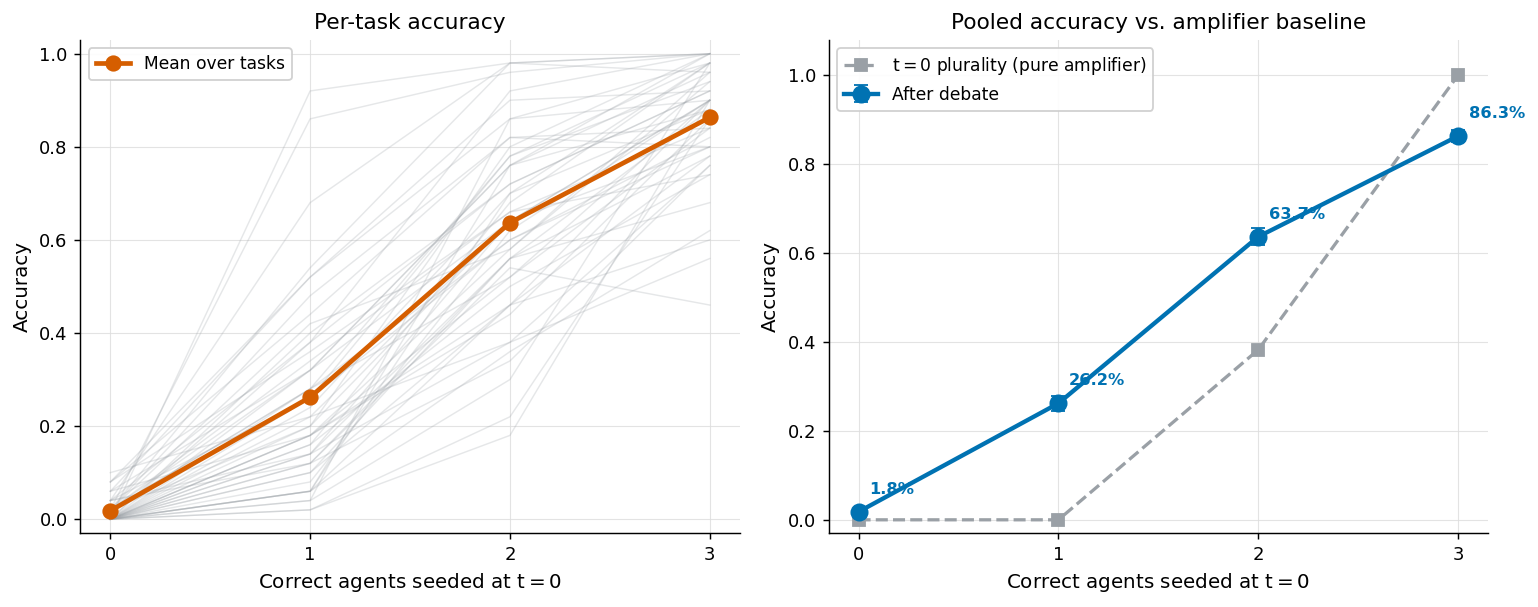

saved ../../thesis/plots/highrep/fig4_seeded_causal.png


In [4]:
# --- fig4_seeded_causal: (a) per-task spaghetti + mean, (b) pooled vs amplifier baseline ---
ci = [wilson(pooled[i], len(data[CONDS[i]])) for i in range(4)]
fig, ax = plt.subplots(1, 2, figsize=FIGSIZES['twopanel'])
for q in tasks:
    ax[0].plot(CONDS, [T[k][q] for k in CONDS], color=GREY, alpha=0.25, linewidth=0.8)
ax[0].plot(CONDS, pooled, color=ORANGE, linewidth=2.6, marker='o', markersize=8, zorder=5, label='Mean over tasks')
ax[0].set_xticks(CONDS); ax[0].set_xlabel('Correct agents seeded at $t=0$'); ax[0].set_ylabel('Accuracy')
ax[0].set_ylim(-0.03, 1.03); ax[0].set_title('Per-task accuracy'); ax[0].legend(loc='upper left'); ax[0].set_axisbelow(True)
lo = [pooled[i] - ci[i][0] for i in range(4)]; hi = [ci[i][1] - pooled[i] for i in range(4)]
ax[1].errorbar(CONDS, pooled, yerr=[lo, hi], color=BLUE, marker='o', markersize=9, linewidth=2.4, capsize=4, label='After debate', zorder=5)
ax[1].plot(CONDS, base, color=GREY, linestyle='--', marker='s', markersize=7, linewidth=1.8, label='$t=0$ plurality (pure amplifier)')
for i, k in enumerate(CONDS):
    ax[1].annotate(f'{pooled[i]:.1%}', (k, pooled[i]), textcoords='offset points', xytext=(6, 10), fontsize=9, fontweight='bold', color=BLUE)
ax[1].set_xticks(CONDS); ax[1].set_xlabel('Correct agents seeded at $t=0$'); ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(-0.03, 1.08); ax[1].set_title('Pooled accuracy vs. amplifier baseline'); ax[1].legend(loc='upper left'); ax[1].set_axisbelow(True)
fig.tight_layout()
fig.savefig(f'{EXPORT}/fig4_seeded_causal.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved', f'{EXPORT}/fig4_seeded_causal.png')